In [2]:
suppressMessages(library(Seurat))
suppressMessages(library(dplyr))
suppressMessages(library(stringr))
suppressMessages(library(ggplot2))
suppressMessages(library(data.table))
suppressMessages(library(sctransform))

In [3]:
library(copykat)

In [4]:
meta_big_sur <- read.csv("metadata_all_cells_bigsur_merged.csv", row.names = 1)

In [5]:
full <- readRDS("blg_cre_khaled_all_cells.rds")

In [6]:
cell_names <- full$barcode
full <- RenameCells(full, new.names = cell_names)

In [8]:
full <- AddMetaData(full, meta_big_sur['cell_type'], 'cell_type')

In [9]:
sub <- subset(full, subset = cell_type %in% c("Cancer_epithelial","Basal_myoepithelial","Luminal_Sec"))

Warning message:
“Removing 69089 cells missing data for vars requested”


In [10]:
table(sub$SampleID)


     CBLA13        CBLT      CTRL_1      CTRL_2      CTRL_3 WKBR61.4dMG 
       1489        2011         453         864         313        1630 
WKBR61.4dTM   WKBR65.2f   WKBR65.2g   WKBR65.3g   WKBR65.3h   WKBR65.3i 
       3092        3319        2541         962        1369         569 
WKBR75.4bMG WKBR75.4bTM   WKBR76.4f   WKBR90.3g   WKBR90.3i   WKBR91.1e 
       1943          29         706        1214         821        1023 
  WKBR91.1f   WKBR91.3j 
       1307         325 

In [11]:
sub <- subset(sub, subset = SampleID %in% c("CBLA13","CBLT"),
             invert = T)

In [12]:
sub

An object of class Seurat 
21772 features across 22480 samples within 1 assay 
Active assay: RNA (21772 features, 0 variable features)
 2 layers present: counts, data
 2 dimensional reductions calculated: corrected, UMAP

In [14]:
ls()

[1] "cell_names" "sub"

In [15]:
rm(cell_names)
rm(full)
rm(meta_big_sur)
gc()

Warning message in rm(full):
“object 'full' not found”
Warning message in rm(meta_big_sur):
“object 'meta_big_sur' not found”


,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,3395098,181.4,6964578,372.0,6964578,372.0
Vcells,159749966,1218.8,1122520504,8564.2,1575297485,12018.6


In [16]:
exp.rawdata <- as.matrix(sub@assays$RNA@counts)

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 3.6 GiB”


In [17]:
Idents(sub) <- "SampleID"

In [18]:
norm <- WhichCells(sub, ident = c("CTRL_2","CTRL_3"))

In [19]:
length(norm)

[1] 1177

In [20]:
copykat.test <- copykat(rawmat=exp.rawdata, id.type="S", ngene.chr=5, win.size=25, KS.cut=0.1, sam.name="ctrl2ctrl3_asnorm_from_all", 
                        distance="euclidean", norm.cell.names=norm,output.seg="FLASE", plot.genes="TRUE", 
                        genome="mm10",n.cores=4)

[1] "running copykat v1.1.0"
[1] "step1: read and filter data ..."
[1] "21772 genes, 22480 cells in raw data"
[1] "8692 genes past LOW.DR filtering"
[1] "step 2: annotations gene coordinates ..."
[1] "start annotation ..."
[1] "step 3: smoothing data with dlm ..."
[1] "step 4: measuring baselines ..."
[1] "1177 known normal cells found in dataset"
[1] "run with known normal..."
[1] "baseline is from known input"
[1] "step 5: segmentation..."
[1] "step 8: final prediction ..."
[1] "step 9: saving results..."
[1] "step 10: ploting heatmap ..."
Time difference of 4.907766 hours


In [21]:
pred <- read.csv("ctrl2ctrl3_asnorm_from_all_copykat_prediction.txt", sep = '\t')

In [22]:
rownames(pred) <- pred$cell.names
pred$cell.names <- NULL
sub <- AddMetaData(sub,pred)

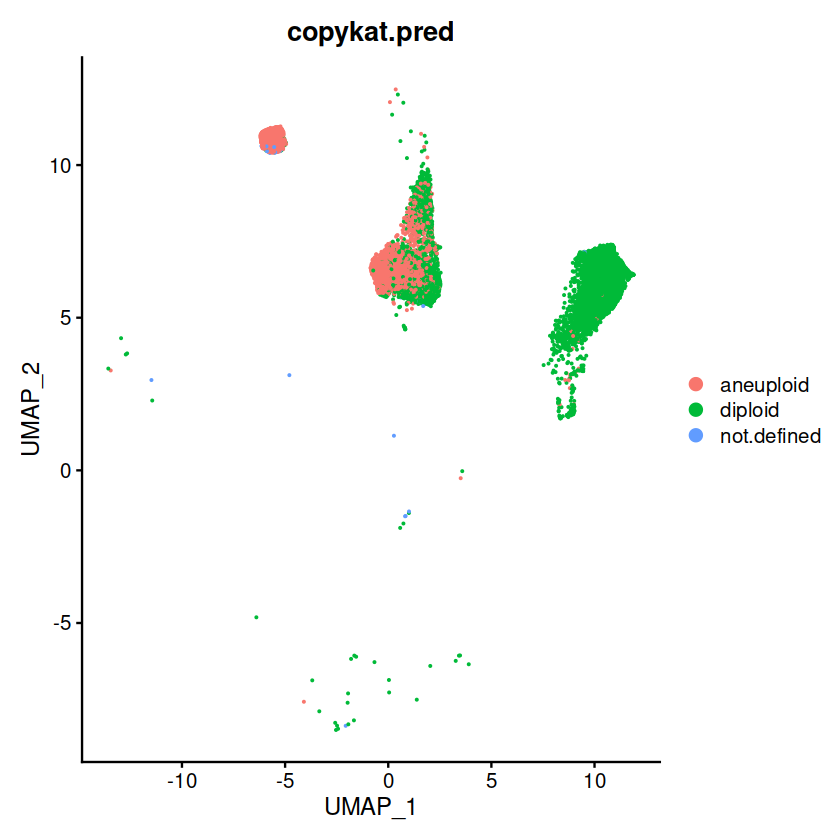

In [24]:
DimPlot(sub, group.by="copykat.pred")

In [20]:
Idents(sub) <- "cellTypesFinal"
sub <- RenameIdents(object = sub, 
                    `Avd` = "LumSec",
                    `Bsl1` = "Basal",
                    `Bsl2` = "Basal",
                    `BslG` = "Basal",
                    `Lp` = "LumSec",
                    `LpBsl` = "LumSec",
                    `Tm` = "Tumor"
                    
                          )
sub$Cell.type <- sub@active.ident

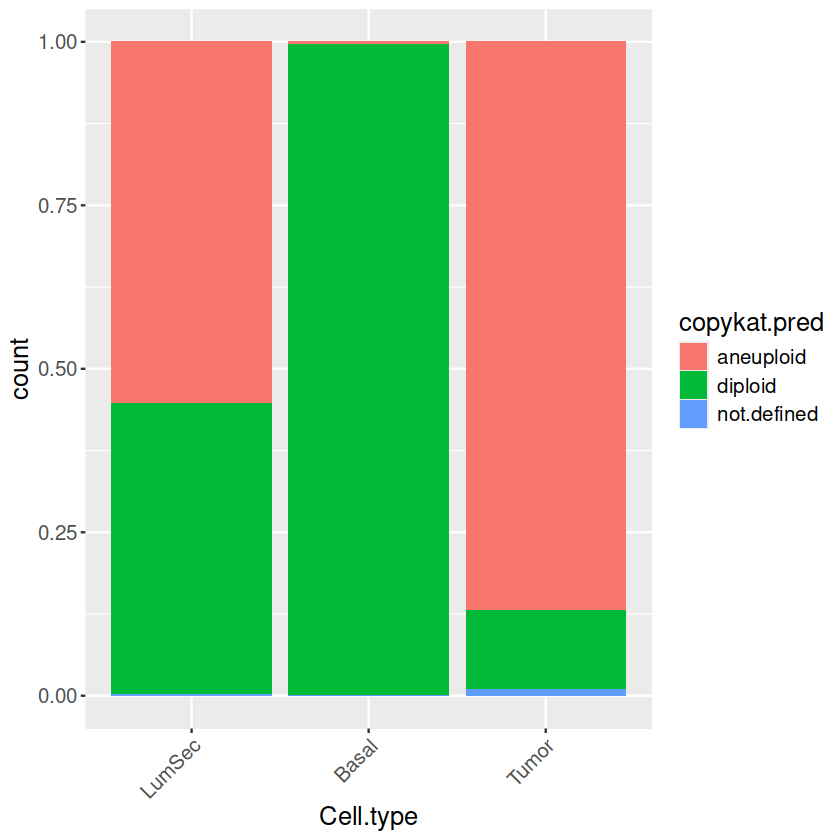

In [21]:
ggplot(sub[[]], aes(x=Cell.type,
                          fill=copykat.pred)) + 
geom_bar(position = 'fill')+ 
theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust=1))+ 
theme(text=element_text(size=15))

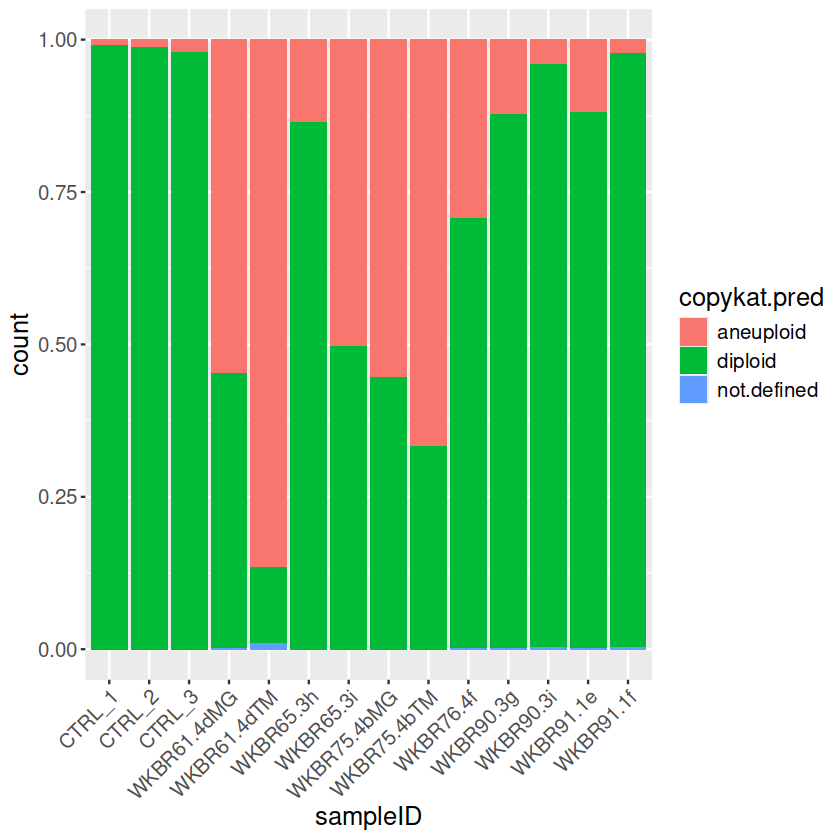

In [31]:
ggplot(sub[[]], aes(x=sampleID,
                          fill=copykat.pred)) + 
geom_bar(position = 'fill')+ 
theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust=1))+ 
theme(text=element_text(size=15))

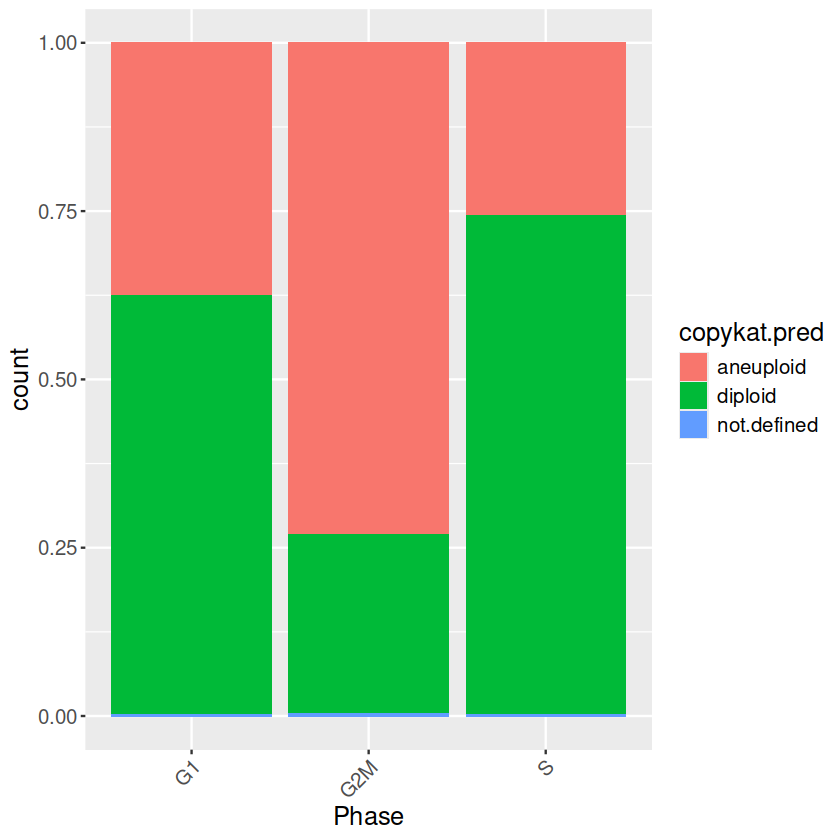

In [30]:
ggplot(sub[[]], aes(x=Phase,
                          fill=copykat.pred)) + 
geom_bar(position = 'fill')+ 
theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust=1))+ 
theme(text=element_text(size=15))

In [35]:
saveRDS(sub[[]], "basal_lumsec_tumor_subset_copykat.rds")

In [10]:
sub <- readRDS("basal_lumsec_tumor_subset_copykat.rds")

In [36]:
write.csv(sub[[]], "basal_lumsec_tumor_subset_copykat.csv")